In [1]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": "CMU Serif",
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}",
        "font.size": 12,
        "font.weight": "normal",
        "figure.titlesize": "medium",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "savefig.dpi": 300,
        "figure.dpi": 150,
        "savefig.bbox": "tight",
    }
)


tender_order = [
    "Measles",
    "Mumps",
    "Rubella",
    'MMR',
    "Diphtheria",
    "Tetanus",
    "Pertussis",
    "Hib",
    "Polio",
    "Hepatitis_B",
    "Penta",
    "HPV",
    "PCV",
    "Rotavirus",
]

# #
# # Define colors for each group
# colors = {
#     "MMR Antigens": "blue",
#     "Hexa Antigens": "green",
#     "HPV": "red",
#     "PCV": "purple",
#     "Rota": "orange",
# }

# color_groups = {
#     "MMR Antigens": ["Measles", "Mumps", "Rubella"],
#     "Hexa Antigens": ["Diphtheria", "Tetanus", "Pertussis", "Hib", "Polio", "Hepatitis_B"],
#     "HPV": ["HPV"],
#     "PCV": ["PCV"],
#     "Rota": ["Rotavirus"],
# }

# Define colors for each group with penta/mmr
colors = {
    "MMR Antigens": "blue",
    "MMR":"grey",
    "Hexa Antigens": "green",
    "Penta":"brown",
    "HPV": "red",
    "PCV": "purple",
    "Rota": "orange",
}

color_groups = {
    "MMR Antigens": ["Measles", "Mumps", "Rubella"],
    "MMR" : ["MMR"],
    "Hexa Antigens": ["Diphtheria", "Tetanus", "Pertussis", "Hib", "Polio", "Hepatitis_B"],
    "Penta":["Penta"],
    "HPV": ["HPV"],
    "PCV": ["PCV"],
    "Rota": ["Rotavirus"],
}

In [2]:
with open("Deterministic_results_F_Q_I_S_base_35.json") as json_file:
    F_results = json.load(json_file)

start_DF = pd.read_excel("Starting_point.xlsx", sheet_name="F_start")
start_DF["Value"] = 1
start_DF.rename(columns={"Antigen": "Tender", "Starting": "Start", "Ending": "Finish"}, inplace=True)

# Search results by keyword for F (tender schedules)
grouped_results = {k: v for k, v in F_results.items() if k.startswith("F")}

F_values_df = pd.DataFrame.from_dict(grouped_results, orient="index").reset_index()
F_values_df.columns = ["index", "Value"]
F_values_df[["F", "Tender", "Start", "Finish"]] = F_values_df["index"].str.extract(r"(\w+)\[(\w+),\((\d+), (\d+)\)\]")
F_values_df = F_values_df.astype({"Start": "int32", "Finish": "int32", "Value": "float64"})

F_values_df.drop(['index', 'F'], axis=1, inplace=True)
F_values_df = F_values_df[['Tender', 'Start', 'Finish', 'Value']]

result_df = pd.concat([F_values_df, start_DF], ignore_index=True)
result_df["Tender"] = pd.Categorical(result_df["Tender"], categories=tender_order, ordered=True)
result_df = result_df.sort_values("Tender")

# result_df

In [3]:
with open("MMR_Penta_S2_D2.json") as json_file:
    F_results = json.load(json_file)

start_DF = pd.read_excel("Starting_point.xlsx", sheet_name="F_start")
start_DF["Value"] = 1
start_DF.rename(columns={"Antigen": "Tender", "Starting": "Start", "Ending": "Finish"}, inplace=True)

# Search results by keyword for F (tender schedules)
grouped_results = {k: v for k, v in F_results.items() if k.startswith("F")}

F_values_df = pd.DataFrame.from_dict(grouped_results, orient="index").reset_index()
F_values_df.columns = ["index", "Value"]
F_values_df[["F", "Tender", "Start", "Finish"]] = F_values_df["index"].str.extract(r"(\w+)\[(\w+),\((\d+), (\d+)\)\]")
F_values_df = F_values_df.astype({"Start": "int32", "Finish": "int32", "Value": "float64"})

F_values_df.drop(['index', 'F'], axis=1, inplace=True)
F_values_df = F_values_df[['Tender', 'Start', 'Finish', 'Value']]

result_df_2 = pd.concat([F_values_df, start_DF], ignore_index=True)
result_df_2["Tender"] = pd.Categorical(result_df_2["Tender"], categories=tender_order, ordered=True)
result_df_2 = result_df_2.sort_values("Tender")


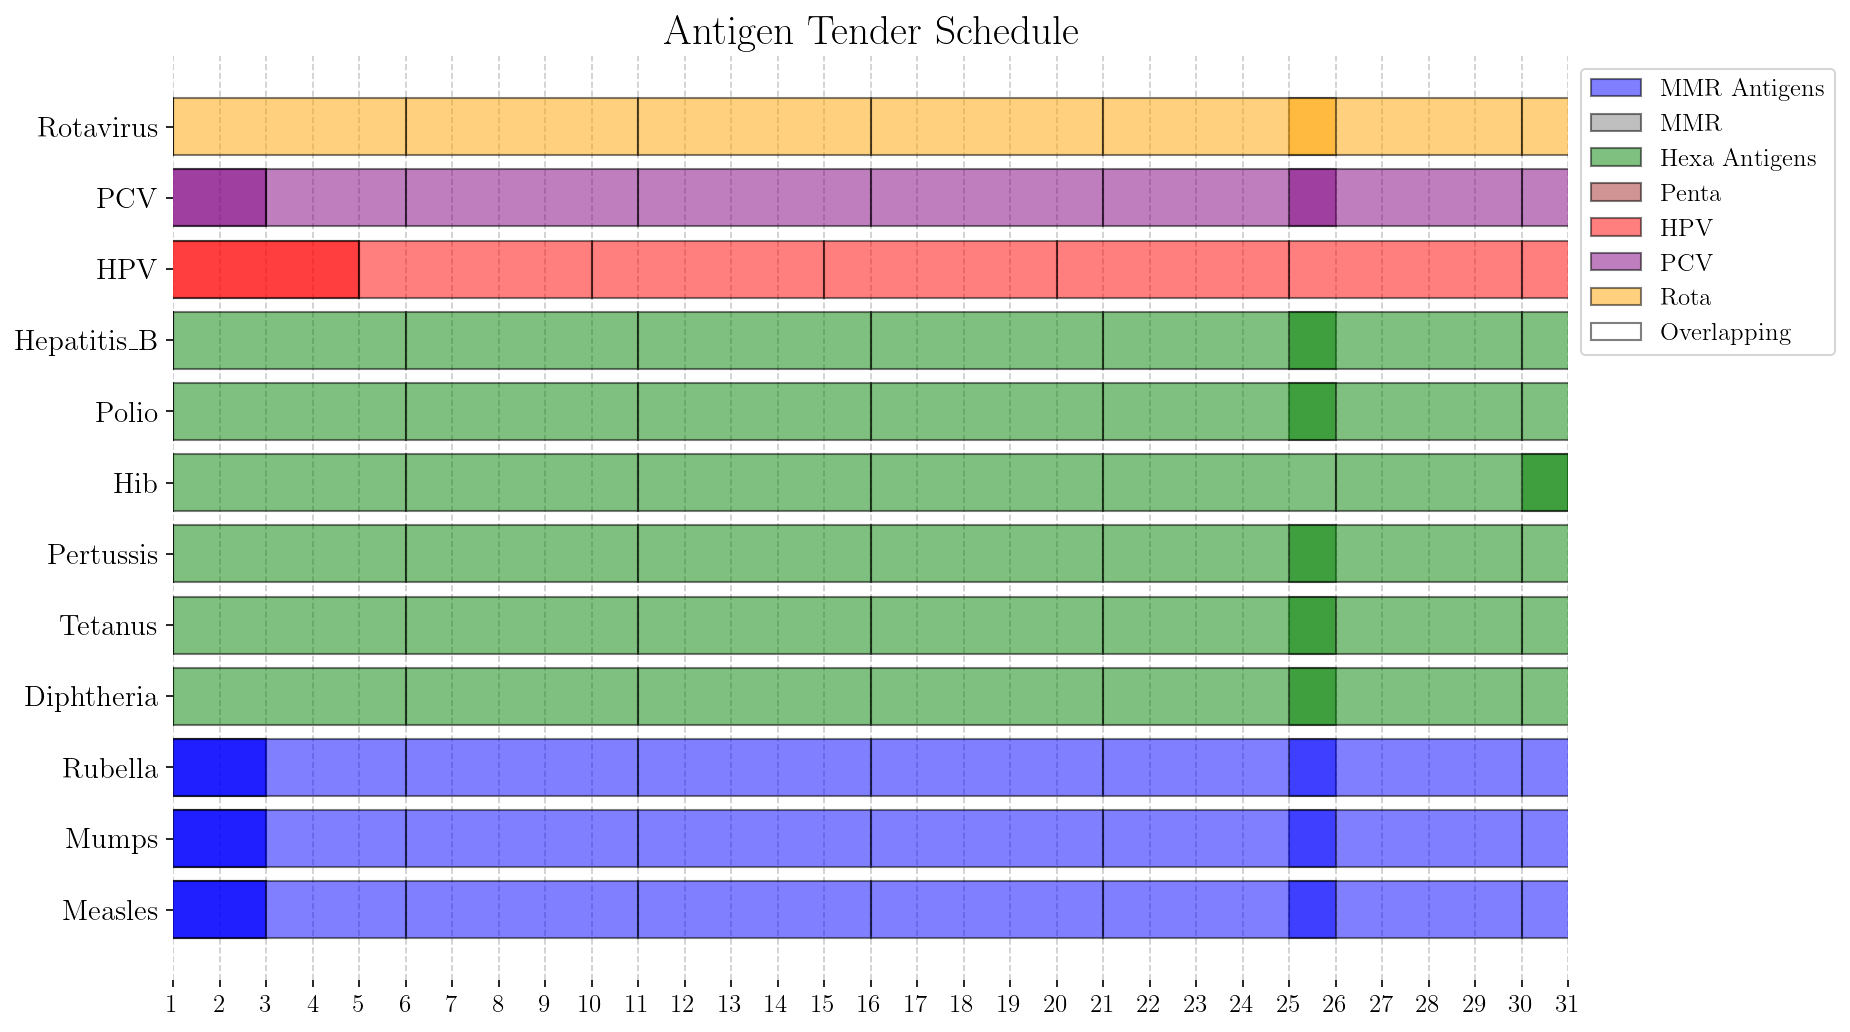

In [8]:
# fig, ax = plt.subplots(figsize=(10, 5))
fig, ax = plt.subplots(figsize=(12, 8))  # Adjust figure size


temp = {}

# Iterate through rows and plot bars based on conditions and color groups
for index, row in result_df.iterrows():
    if round(row["Value"]) == 1:
        start = row["Start"] - 1
        end = row["Finish"]

        # Choose color based on the group
        for group, tenders in color_groups.items():
            if row["Tender"] in tenders:
                x = row["Tender"]
                width = end - start
                left = start
                # print(row["Tender"], group)
                color = colors[group]

                # Check for overlapping bars
                hatch = None
                if x in temp:
                    for overlap_start, overlap_end in temp[x]:
                        if overlap_start < left + width and overlap_end > left:
                            # hatch = "//"
                            break

                # Adjust 'left' parameter for overlapping bars
                ax.barh(x, width=width, left=left, edgecolor="black", facecolor=color, alpha=0.5, zorder=10, hatch=hatch)

                # Update the list of overlapping periods for the current 'Tender'
                if x in temp:
                    temp[x].append((left, left + width))
                else:
                    temp[x] = [(left, left + width)]



# Set labels and show the plot
ax.set_xlim(1, 30)
ax.set_xticks(range(1, 32))

ax.set_title("Antigen Tender Schedule", fontsize=20)
# ax.set_ylabel("Antigen", fontsize=16)  # Set Y-axis label font size

# Increase font size for Y-axis tick labels
ax.tick_params(axis='y', which='major', labelsize=14)

ax.spines[["right", "top", "bottom", "left"]].set_visible(False)
ax.grid(True, which="both", axis="x", ls="--", c="0.8")

# Create a legend with adjusted location
legend_labels = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[group], alpha=0.5, edgecolor="black", label=group)
    for group in color_groups.keys()
] + [plt.Rectangle((0, 0), 1, 1, facecolor="white", alpha=0.5, edgecolor="black", label="Overlapping")]

ax.legend(
    handles=legend_labels,
    loc="upper left",
    bbox_to_anchor=(1, 1),
)

plt.savefig('Tender_Schedule_base.pdf', bbox_inches='tight', pad_inches=0.1, dpi=600)

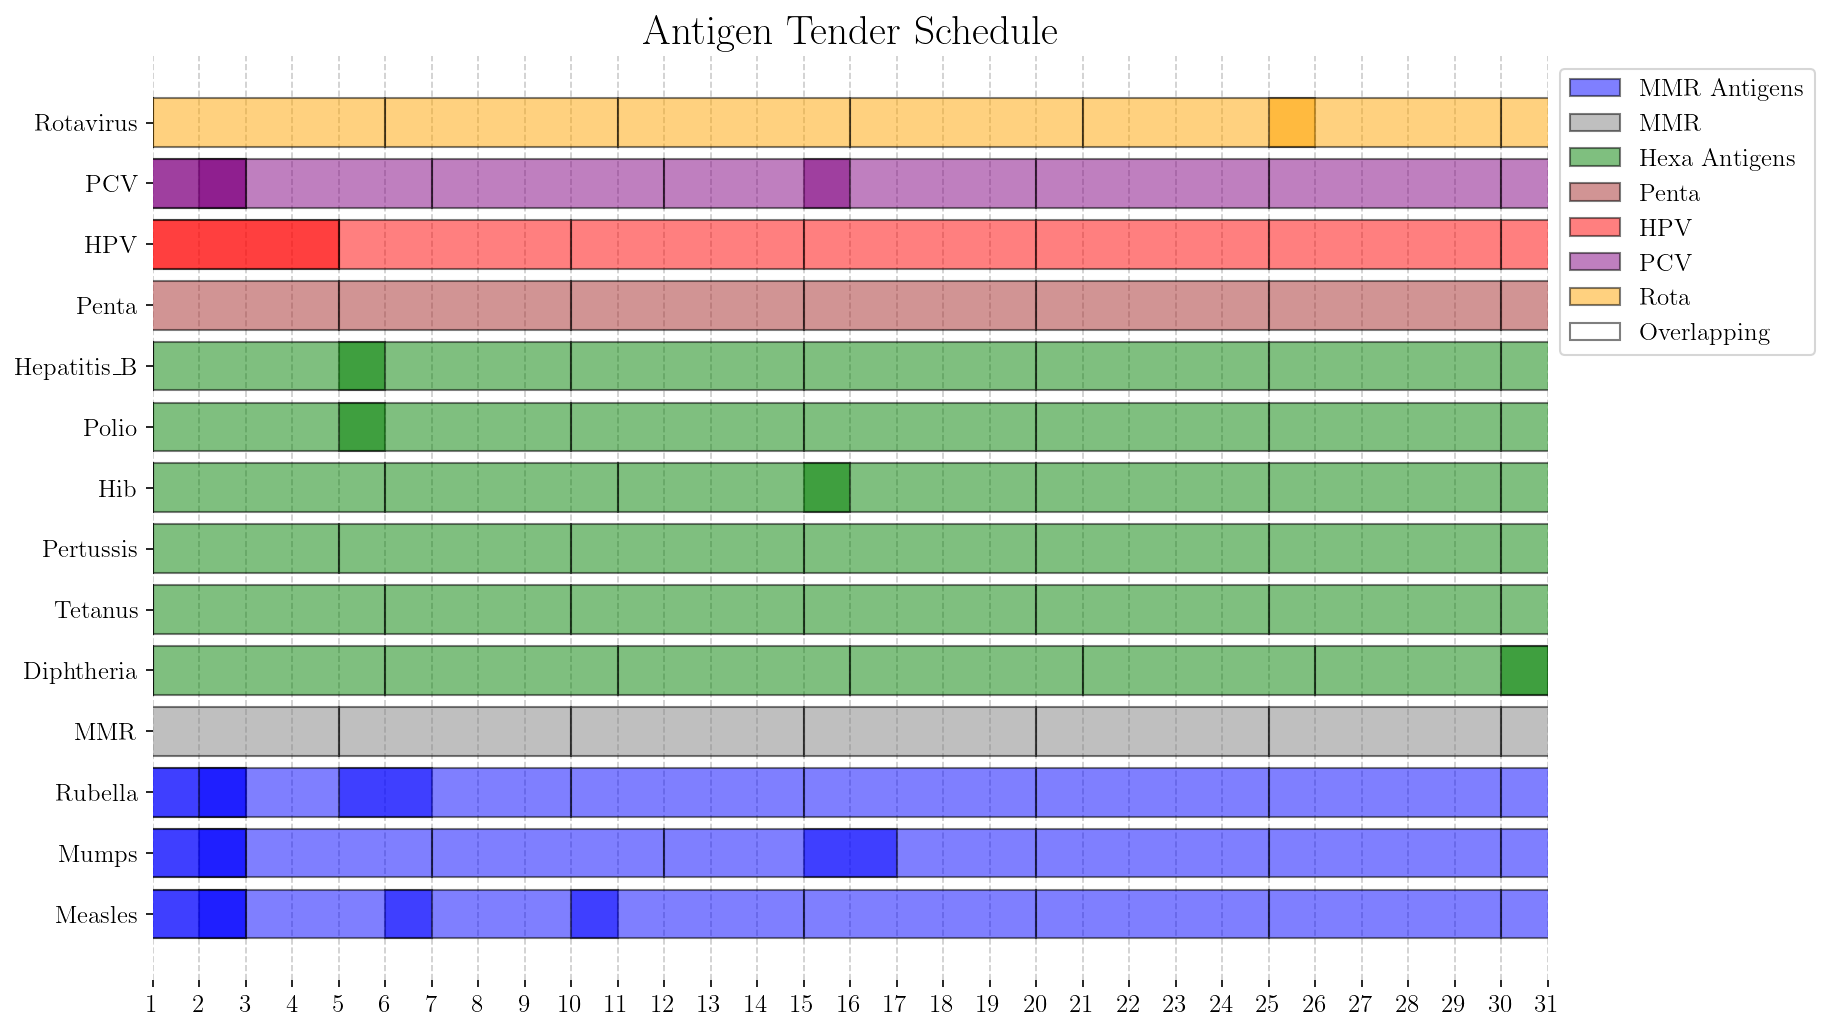

In [10]:
# fig, ax = plt.subplots(figsize=(10, 5))
fig2, ax2 = plt.subplots(figsize=(12, 8))  # Adjust figure size


temp = {}

# Iterate through rows and plot bars based on conditions and color groups
for index, row in result_df_2.iterrows():
    if round(row["Value"]) == 1:
        start = row["Start"] - 1
        end = row["Finish"]

        # Choose color based on the group
        for group, tenders in color_groups.items():
            if row["Tender"] in tenders:
                x = row["Tender"]
                width = end - start
                left = start
                # print(row["Tender"], group)
                color = colors[group]

                # Check for overlapping bars
                hatch = None
                if x in temp:
                    for overlap_start, overlap_end in temp[x]:
                        if overlap_start < left + width and overlap_end > left:
                            # hatch = "//"
                            break

                # Adjust 'left' parameter for overlapping bars
                ax2.barh(x, width=width, left=left, edgecolor="black", facecolor=color, alpha=0.5, zorder=10, hatch=hatch)

                # Update the list of overlapping periods for the current 'Tender'
                if x in temp:
                    temp[x].append((left, left + width))
                else:
                    temp[x] = [(left, left + width)]



# Set labels and show the plot
ax2.set_xlim(1, 30)
ax2.set_xticks(range(1, 32))

ax2.set_title("Antigen Tender Schedule", fontsize=20)
# ax.set_ylabel("Antigen", fontsize=16)  # Set Y-axis label font size

# Increase font size for Y-axis tick labels
ax.tick_params(axis='y', which='major', labelsize=14)

ax2.spines[["right", "top", "bottom", "left"]].set_visible(False)
ax2.grid(True, which="both", axis="x", ls="--", c="0.8")

# Create a legend with adjusted location
legend_labels = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[group], alpha=0.5, edgecolor="black", label=group)
    for group in color_groups.keys()
] + [plt.Rectangle((0, 0), 1, 1, facecolor="white", alpha=0.5, edgecolor="black", label="Overlapping")]

ax2.legend(
    handles=legend_labels,
    loc="upper left",
    bbox_to_anchor=(1, 1),
)

plt.savefig('Tender_Schedule_MMR.pdf', bbox_inches='tight', pad_inches=0.1, dpi=600)

In [6]:
figs, axes = plt.subplots(fig, fig2, figsize=(12, 8), sharey=True, gridspec_kw={"width_ratios": [1, 1]})
cur_ax = axes[0]

ValueError: Number of rows must be a positive integer, not <Figure size 1800x1200 with 1 Axes>

<Figure size 1800x1200 with 0 Axes>